In [62]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')   # 'Agg' = save to file instead of opening a window
                        # Needed because we are running in a headless environment
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec   # controls subplot layout
import matplotlib.patches as mpatches   # draws shapes (used in Fig 9)
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import norm as sp_norm  # Normal distribution CDF and PDF
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, mean_absolute_percentage_error)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
import warnings, time
warnings.filterwarnings('ignore')  # suppress harmless GP convergence warnings

np.random.seed(42)  # Fix the random seed  same results every run (reproducibility)

print("=" * 68)
print("  ACTIVE LEARNING — AUTONOMOUS BATTERY MATERIALS DISCOVERY")
print("=" * 68)

  ACTIVE LEARNING — AUTONOMOUS BATTERY MATERIALS DISCOVERY


In [63]:
# STAGE 1 — DATASET SIMULATION

# WHAT THIS DOES:
#   Creates a fake-but-realistic battery dataset (120 cells).
#   Each row = one battery cell that was tested in a lab.
#   Each column = one measurement taken from that cell.
#
#   We simulate instead of using real data because:
#     1. The real NASA dataset needs downloading and cleaning
#     2. Our simulation uses the SAME physics equations as real degradation
#     3. You can control exactly what patterns appear (good for teaching)
#
# THE 9 FEATURES (what we measure in the lab):
#   temp_rise         → How many °C the battery heats up per cycle
#   voltage_variance  → How unstable the voltage is (bad = high variance)
#   ir_growth_rate    → How fast internal resistance grows (SEI film)
#   charge_time_drift → How much longer charging takes over time
#   dqdv_peak_shift   → Shift in the dQ/dV curve (cathode phase change)
#   depth_of_discharge → How deeply we drain the battery (0=gentle, 1=full)
#   charge_rate       → How fast we charge (1C=1hr, 3C=20min)
#   operating_temp    → Room temperature during tests
#   cycle_index       → Which cycle we measured this at (how old the cell is)
#
# THE TARGET:
#   rul = Remaining Useful Life (how many cycles until 80% capacity)
#   This is what we're trying to PREDICT with machine learning.
#
# KEY PHYSICS EQUATIONS USED:
#   SEI growth:     R_sei ∝ √N  (parabolic — like rust thickening on metal)
#   Arrhenius:      k(T) = A·exp(-Ea/RT)  (heat doubles reaction speed)
#   RUL formula:    RUL = starting_budget − (SEI penalty) − (thermal penalty)
#                         − (voltage penalty) − ...

def simulate_nasa_battery_dataset(n_cells=120, seed=42):
    rng = np.random.default_rng(seed)

    # --- Each cell gets its own test conditions ---
    nominal_rul  = rng.uniform(300, 1500, n_cells)
    dod_vals     = rng.uniform(0.5, 1.0, n_cells)
    c_rate_vals  = rng.uniform(0.5, 3.0, n_cells)
    temp_vals    = rng.uniform(15, 55, n_cells)

    # --- Compute each feature from the test conditions ---

    # IR growth: more aggressive charging + hotter = faster SEI film growth
    ir_growth = (0.0015 * c_rate_vals
                 + 0.00008 * (temp_vals - 25)
                 + rng.normal(0, 0.0003, n_cells)).clip(0, 0.01)


    # Arrhenius factor: how much faster reactions are at this temperature vs 25°C
    # Ea/R = 3800 K means energy barrier ≈ 32 kJ/mol (measured for SEI in literature)
    Ea_R    = 3800.0
    T_ref   = 298.0
    k_thermal = np.exp(-Ea_R * (1/(temp_vals + 273) - 1/T_ref))

    # Voltage variance: high DoD + high C-rate = more electrochemical stress = more variance
    volt_var = (0.0018 * dod_vals
                + 0.0025 * c_rate_vals
                + 0.0003 * k_thermal
                + rng.normal(0, 0.0004, n_cells)).clip(0, 0.02)

    # Temperature rise per cycle (how hot the cell gets during one charge-discharge)
    temp_rise = (0.4 * c_rate_vals
                 + 0.15 * dod_vals * c_rate_vals
                 + rng.normal(0, 0.3, n_cells)).clip(0.1, 8.0)

    # Charge time drift: SEI makes cell charge slower over time
    charge_drift = (0.5 * ir_growth * 1000
                    + 0.12 * (dod_vals - 0.5)
                    + rng.normal(0, 0.05, n_cells)).clip(0, 2.0)

    # dQ/dV peak shift: negative because peak shifts to lower voltage as cell ages
    dqdv_shift = (-0.008 * c_rate_vals
                  - 0.005 * k_thermal
                  - 0.003 * ir_growth * 500
                  + rng.normal(0, 0.003, n_cells)).clip(-0.05, 0)

    # Cycle index = which cycle the measurement was taken at (older cells have higher index)
    cycle_idx = rng.integers(10, 300, n_cells).astype(float)

    # --- Compute the TARGET (RUL) ---
    # This formula says: start with a budget, then subtract penalties for each stress factor
    # The coefficients (180_000, 12_000, etc.) were tuned to give realistic RUL ranges
    rul = (
        nominal_rul
        - 180_000 * ir_growth
        - 12_000  * volt_var
        - 3.5     * temp_rise**1.4
        - 280     * (dod_vals - 0.5)
        - 180     * (c_rate_vals - 0.5)
        - 1.8     * cycle_idx
        + rng.normal(0, 25, n_cells)
    ).clip(10, 1400)


    df = pd.DataFrame({
        'temp_rise'         : np.round(temp_rise,  3),
        'voltage_variance'  : np.round(volt_var,   5),
        'ir_growth_rate'    : np.round(ir_growth,  6),
        'charge_time_drift' : np.round(charge_drift, 3),
        'dqdv_peak_shift'   : np.round(dqdv_shift, 4),
        'depth_of_discharge': np.round(dod_vals,   3),
        'charge_rate'       : np.round(c_rate_vals, 2),
        'operating_temp'    : np.round(temp_vals,  1),
        'cycle_index'       : cycle_idx.astype(int),
        'rul'               : np.round(rul, 1),
    })
    return df

import os

print("\n[Stage 1] Simulating NASA-style battery dataset...")
df = simulate_nasa_battery_dataset(n_cells=120)

output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, 'battery_rul_dataset.csv'), index=False)  # save to disk
print(f"  Cells: {len(df)} | RUL range: {df['rul'].min():.0f}–{df['rul'].max():.0f} cycles")

FEATURES = [c for c in df.columns if c != 'rul']  # all column names except the target
FEAT_LABELS = {  # human-readable names for plots
    'temp_rise':         'Temp Rise (°C/cycle)',
    'voltage_variance':  'Voltage Variance (V²)',
    'ir_growth_rate':    'IR Growth Rate (Ω/cycle)',
    'charge_time_drift': 'Charge Time Drift (min)',
    'dqdv_peak_shift':   'dQ/dV Peak Shift (V)',
    'depth_of_discharge':'Depth of Discharge',
    'charge_rate':       'Charge Rate (C)',
    'operating_temp':    'Operating Temp (°C)',
    'cycle_index':       'Cycle Index',
}


[Stage 1] Simulating NASA-style battery dataset...
  Cells: 120 | RUL range: 10–936 cycles


In [64]:
# STAGE 2 — FEATURE ENGINEERING

print("\n[Stage 2] Feature engineering + EDA...")

# Combined stress = how much thermal AND electrical stress happened together
df['thermal_stress_idx']  = df['temp_rise'] * df['charge_rate']

# Cumulative SEI = resistance growth rate × how many cycles already done
# = proxy for total SEI film thickness (the older + faster-growing, the worse)
df['sei_severity']        = df['ir_growth_rate'] * df['cycle_index']

# Electrochemical risk = voltage instability × how aggressively we charged
df['electrochemical_risk']= df['voltage_variance'] * df['charge_rate']

# Combined mechanical-electrochemical stress
df['dod_c_interaction']   = df['depth_of_discharge'] * df['charge_rate']

ALL_FEATURES = FEATURES + ['thermal_stress_idx', 'sei_severity',
                            'electrochemical_risk', 'dod_c_interaction']

X = df[ALL_FEATURES].values
y = df['rul'].values

# StandardScaler: for each feature → subtract mean, divide by std
# After scaling: every feature has mean=0 and std=1
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)



[Stage 2] Feature engineering + EDA...


In [65]:
# STAGE 3 — GAUSSIAN PROCESS SURROGATE MODEL
# WHAT THIS DOES:
#   Trains a Gaussian Process (GP) model on a SUBSET of the data (30 cells).
#   The GP is special because it gives us TWO outputs per prediction:
#     μ(x)  = the best guess for RUL   ("I think this battery has 450 cycles left")
#     σ(x)  = how uncertain we are     ("...but I could be off by ±80 cycles"
# WHY GAUSSIAN PROCESS INSTEAD OF NEURAL NETWORK?
#   Neural networks need thousands of training examples to work well.
#   GPs work great with just 30-100 examples — perfect for expensive lab tests.
#   And crucially, NNs don't give you reliable uncertainty estimates. GPs do.
#   Matérn 5/2 is preferred for physical systems because:
#   - It assumes the function is smooth but not "perfect" (not infinitely smooth)
#   - Physical systems like battery degradation are exactly like this
#
# THE SPLIT:
#   30 cells → initial labeled training set (we "ran these experiments already")
#   90 cells → unlabeled pool (we haven't tested these yet)
#   Active learning will pick from the pool one-by-one.

print("\n[Stage 3] Gaussian Process surrogate model...")

# Build the kernel: product of constant × Matérn, plus noise

kernel = (ConstantKernel(constant_value=1.0, constant_value_bounds=(0.1, 10.0))
          * Matern(length_scale=1.0, length_scale_bounds=(0.01, 10.0), nu=2.5)
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1.0)))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42
)

# Create the initial labeled / unlabeled split
idx_all   = np.arange(len(X_scaled))
np.random.shuffle(idx_all)
n_init    = 30
idx_train = idx_all[:n_init]
idx_pool  = idx_all[n_init:]

X_train_init = X_scaled[idx_train]
y_train_init = y[idx_train]
X_pool       = X_scaled[idx_pool]
y_pool       = y[idx_pool]

# Fit the GP on just the 30 labeled cells
gp.fit(X_train_init, y_train_init)

# Predict on the pool: get BOTH mean AND standard deviation
# return_std=True is the key line — this is what gives us uncertainty
mu_pool, sigma_pool = gp.predict(X_pool, return_std=True)

print(f"  Initial labeled pool: {n_init} cells")
print(f"  Unlabeled pool: {len(idx_pool)} cells")
print(f"  GP uncertainty range: σ=[{sigma_pool.min():.1f}, {sigma_pool.max():.1f}] cycles")



[Stage 3] Gaussian Process surrogate model...
  Initial labeled pool: 30 cells
  Unlabeled pool: 90 cells
  GP uncertainty range: σ=[67.8, 244.6] cycles


In [66]:
# STAGE 4 — ACTIVE LEARNING LOOP
#
# WHAT THIS DOES:
#   Simulates what an AUTONOMOUS LABORATORY does:
#   1. Fit the GP on currently labeled cells
#   2. Ask: "Which unlabeled cell would teach us the most?"
#   3. "Run that experiment" (reveal its true RUL from the pool)
#   4. Add it to the labeled set
#   5. Re-fit the GP with the new information
#   6. Repeat 50 times
#
# THREE STRATEGIES COMPARED:
#   'uncertainty' (US) → always pick the cell with highest σ(x)
#                         = "I'm most confused about this one, let me test it"
#   'ei'           (EI) → pick the cell most likely to beat the current best RUL
#                         = "This one might be the highest-performing battery"
#   'random'            → pick randomly, no intelligence
#                         = baseline (proves the AI strategy actually helps)
#
# THE KEY FUNCTION: expected_improvement()
#   EI(x) = σ(x) · [z·Φ(z) + φ(z)]
#   where z = (μ(x) - y_best - ξ) / σ(x)
#   Φ = normal CDF (probability of improving)
#   φ = normal PDF  (probability density)
#   ξ = small bonus for exploration (0.01 = slightly prefer unexplored regions)
#
#   MEANING: EI is high when either μ(x) is high (looks promising) OR
#            σ(x) is high (very uncertain, might be surprisingly good).
#            This naturally balances exploitation vs exploration.

print("\n[Stage 4] Active learning loop...")

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    EI(x) = how much improvement we EXPECT if we test point x.
    y_best = the best RUL we've seen so far in our labeled set.
    xi     = tiny bonus to prevent getting stuck (exploration term).
    """
    sigma = np.maximum(sigma, 1e-9)
    z     = (mu - y_best - xi) / sigma
    # sp_norm.cdf = Φ(z) = probability that a standard Normal is below z
    # sp_norm.pdf = φ(z) = height of Normal curve at z
    ei    = sigma * (z * sp_norm.cdf(z) + sp_norm.pdf(z))
    return ei


def run_active_learning(X_all, y_all, n_init=30, n_queries=30,
                        strategy='uncertainty', seed=42):
    """
    Run the full active learning loop.
    Returns a history dict tracking performance after each query.
    """
    rng     = np.random.default_rng(seed)
    idx_all = np.arange(len(X_all))
    rng.shuffle(idx_all)

    labeled = list(idx_all[:n_init])
    pool    = list(idx_all[n_init:])

    # Hold out 20 cells as a fixed test set — never queried, only used for evaluation
    test_idx  = idx_all[-20:]
    X_test_al = X_all[test_idx]
    y_test_al = y_all[test_idx]
    pool      = [i for i in pool if i not in test_idx]

    history = {'n_labeled': [], 'rmse': [], 'r2': [], 'mae': []}
    kernel_al = (ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
                 + WhiteKernel(noise_level=0.1))

    for step in range(n_queries):
        #  Fit GP on current labeled set
        gp_al = GaussianProcessRegressor(
            kernel=kernel_al, normalize_y=True,
            n_restarts_optimizer=3, random_state=42
        )
        gp_al.fit(X_all[labeled], y_all[labeled])

        #  Measure accuracy on fixed test set
        y_pred_test, _ = gp_al.predict(X_test_al, return_std=True)
        history['n_labeled'].append(len(labeled))
        history['rmse'].append(np.sqrt(mean_squared_error(y_test_al, y_pred_test)))
        history['r2'].append(r2_score(y_test_al, y_pred_test))
        history['mae'].append(mean_absolute_error(y_test_al, y_pred_test))

        if len(pool) == 0:
            break

        #  Pick the next cell to test using the acquisition strategy
        X_pool_al       = X_all[pool]
        mu_al, sigma_al = gp_al.predict(X_pool_al, return_std=True)

        if strategy == 'uncertainty':
            acq_scores = sigma_al
        elif strategy == 'ei':
            y_best     = max(y_all[labeled])
            acq_scores = expected_improvement(mu_al, sigma_al, y_best)
        elif strategy == 'random':
            acq_scores = rng.random(len(pool))  # no intelligence, just random

        #  "Run the experiment" — reveal the true RUL of the best candidate
        best_pool_idx = np.argmax(acq_scores)
        selected      = pool[best_pool_idx]
        labeled.append(selected)
        pool.pop(best_pool_idx)

    return history


print("  Running Uncertainty Sampling (US)...")
hist_us     = run_active_learning(X_scaled, y, n_init=30, n_queries=50, strategy='uncertainty')

print("  Running Expected Improvement (EI)...")
hist_ei     = run_active_learning(X_scaled, y, n_init=30, n_queries=50, strategy='ei')

print("  Running Random Baseline...")
hist_random = run_active_learning(X_scaled, y, n_init=30, n_queries=50, strategy='random')

# How many labels needed to hit our target accuracy?
target_rmse = 80
def labels_to_reach_target(hist, target):
    for i, r in enumerate(hist['rmse']):
        if r <= target:
            return hist['n_labeled'][i]
    return hist['n_labeled'][-1]

us_labels     = labels_to_reach_target(hist_us, target_rmse)
ei_labels     = labels_to_reach_target(hist_ei, target_rmse)
random_labels = labels_to_reach_target(hist_random, target_rmse)



[Stage 4] Active learning loop...
  Running Uncertainty Sampling (US)...
  Running Expected Improvement (EI)...
  Running Random Baseline...


In [67]:
# STAGE 5 — MODEL COMPARISON

# WHAT THIS DOES:
#   Trains 4 different models on the FULL dataset (not just 30 cells).
#   Compares them on a 25% held-out test set.
#   Shows WHY the GP is special — only it gives calibrated uncertainty.
#
#   The 4 models:
#   Ridge Regression → simple linear model (baseline)
#   Random Forest    → many decision trees voting together
#   Gradient Boosting→ trees built sequentially, each fixing the previous
#   Gaussian Process → our surrogate, gives μ AND σ
#
#   train_test_split: randomly puts 75% in training, 25% in test
#   The model NEVER sees the test set during training — honest evaluation.

print("\n[Stage 5] Full model comparison (GP vs baselines)...")

from sklearn.model_selection import train_test_split
# test_size=0.25 → 25% of 120 cells = 30 test cells, 90 training cells
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Ridge Regression: fits a weighted sum of features (linear relationship)
# alpha=10.0 = regularization strength (prevents overfitting)
ridge = Ridge(alpha=10.0)
ridge.fit(X_tr, y_tr)
ridge_pred = ridge.predict(X_te)
ridge_r2   = r2_score(y_te, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_te, ridge_pred))

# Random Forest: 200 decision trees, each sees random subset of features
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_te)
rf_r2   = r2_score(y_te, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_te, rf_pred))

# Gradient Boosting: builds 300 trees sequentially (each one corrects the previous)
# learning_rate=0.05 = small step size (prevents overfitting)
gb = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                learning_rate=0.05, random_state=42)
gb.fit(X_tr, y_tr)
gb_pred = gb.predict(X_te)
gb_r2   = r2_score(y_te, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_te, gb_pred))

# Gaussian Process: same model as Stage 3 but trained on full 90-cell training set
gp_full = GaussianProcessRegressor(
    kernel=(ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
            + WhiteKernel(noise_level=0.1)),
    normalize_y=True, n_restarts_optimizer=5, random_state=42
)
gp_full.fit(X_tr, y_tr)
# return_std=True gives us σ in addition to μ — unique capability of GP
gp_pred, gp_std = gp_full.predict(X_te, return_std=True)
gp_r2   = r2_score(y_te, gp_pred)
gp_rmse = np.sqrt(mean_squared_error(y_te, gp_pred))

print(f"  Ridge:             R²={ridge_r2:.4f}  RMSE={ridge_rmse:.2f}")
print(f"  Random Forest:     R²={rf_r2:.4f}  RMSE={rf_rmse:.2f}")
print(f"  Gradient Boosting: R²={gb_r2:.4f}  RMSE={gb_rmse:.2f}")
print(f"  Gaussian Process:  R²={gp_r2:.4f}  RMSE={gp_rmse:.2f}  (+ uncertainty σ)")



[Stage 5] Full model comparison (GP vs baselines)...
  Ridge:             R²=0.2545  RMSE=192.45
  Random Forest:     R²=0.4633  RMSE=163.29
  Gradient Boosting: R²=0.5114  RMSE=155.80
  Gaussian Process:  R²=-0.0001  RMSE=222.89  (+ uncertainty σ)


In [68]:
# STAGE 6 — XAI (SHAP-PROXY ANALYSIS)

# WHAT THIS DOES:
#   Answers the question: "Which feature matters most for predicting RUL?"
#   This is called Explainable AI (XAI).
#
# METHOD: Permutation Importance
#   Algorithm:
#     1. Compute baseline R² on test set
#     2. Randomly shuffle feature j (destroys its signal)
#     3. Compute new R² — it drops because we just ruined an important feature
#     4. Importance(j) = how much R² dropped
#     5. Repeat 30 times (n_repeats=30) and take the mean → stable estimate
#
#   High importance = shuffling that feature really hurt the model
#                   = that feature carries real signal about RUL
#
# BEESWARM APPROXIMATION:
#   The right panel is a SHAP-style beeswarm plot.
#   True SHAP (Shapley values) needs the 'shap' package.
#   Our approximation: SHAP_approx(i,j) = sign(r_j) × norm(x_ij) × importance_j
#   Where sign(r_j) = does high feature value increase or decrease RUL?
#   Result: same visual pattern as SHAP, no extra package needed.

print("\n[Stage 6] SHAP-proxy XAI analysis (permutation importance, 30 repeats)...")

perm = permutation_importance(
    gb,
    X_te,
    y_te,
    n_repeats=30,
    random_state=42
)
# perm.importances_mean: average R² drop per feature
# perm.importances_std:  standard deviation across 30 repeats

imp_df = pd.DataFrame({
    'feature':  ALL_FEATURES,
    'imp_mean': perm.importances_mean,
    'imp_std':  perm.importances_std,
}).sort_values('imp_mean', ascending=False).reset_index(drop=True)

imp_df['label'] = imp_df['feature'].apply(
    lambda f: FEAT_LABELS.get(f, f.replace('_', ' ').title()))


[Stage 6] SHAP-proxy XAI analysis (permutation importance, 30 repeats)...


In [69]:

# STAGE 7 — ABLATION STUDY

# WHAT THIS DOES:
#   Tests "what happens when I remove this group of features?"
#   This proves that each feature group genuinely contributes to accuracy.
#   Without ablation, a reviewer could argue: "maybe only 2 features matter
#   and the rest are just noise." Ablation proves them wrong.
#
# 6 CONFIGURATIONS TESTED:
#   1. Full model (all 13 features) — baseline
#   2. Remove degradation signals (ir_growth, voltage_var, temp_rise)
#   3. Remove operational params (DoD, C-rate, operating temp)
#   4. Remove temporal features (cycle_index, charge drift, dQ/dV shift)
#   5. Remove engineered features (thermal stress, SEI severity, etc.)
#   6. Use ONLY degradation signals (3 features)
#
# EXPECTED RESULT:
#   Config 2 should hurt most (degradation signals are most predictive)
#   Config 6 should perform poorly alone (needs operational context)

print("\n[Stage 7] Ablation study (feature group removal)...")

def ablation_rmse(feature_list):
    """Retrain GBM with only the given features, return (RMSE, R²)."""
    col_idx = [ALL_FEATURES.index(f) for f in feature_list]
    X_tr_a, X_te_a = X_tr[:, col_idx], X_te[:, col_idx]
    m = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                   learning_rate=0.05, random_state=42)
    m.fit(X_tr_a, y_tr)
    return np.sqrt(mean_squared_error(y_te, m.predict(X_te_a))), r2_score(y_te, m.predict(X_te_a))

degradation_feats = ['ir_growth_rate', 'voltage_variance', 'temp_rise']
operational_feats = ['depth_of_discharge', 'charge_rate', 'operating_temp']
temporal_feats    = ['cycle_index', 'charge_time_drift', 'dqdv_peak_shift']
engineered_feats  = ['thermal_stress_idx', 'sei_severity',
                      'electrochemical_risk', 'dod_c_interaction']

abl_configs = {
    'Full Model':              ALL_FEATURES,
    'w/o Degradation Signals': [f for f in ALL_FEATURES if f not in degradation_feats],
    'w/o Operational Params':  [f for f in ALL_FEATURES if f not in operational_feats],
    'w/o Temporal Features':   [f for f in ALL_FEATURES if f not in temporal_feats],
    'w/o Engineered Features': [f for f in ALL_FEATURES if f not in engineered_feats],
    'Degradation Signals Only':degradation_feats,
}

abl_results = {}
for name, feats in abl_configs.items():
    rmse_a, r2_a = ablation_rmse(feats)
    abl_results[name] = {'RMSE': rmse_a, 'R²': r2_a}
    print(f"  {name:35s}: RMSE={rmse_a:.2f}  R²={r2_a:.4f}  nFeats={len(feats)}")


[Stage 7] Ablation study (feature group removal)...
  Full Model                         : RMSE=155.85  R²=0.5111  nFeats=13
  w/o Degradation Signals            : RMSE=163.83  R²=0.4597  nFeats=10
  w/o Operational Params             : RMSE=181.38  R²=0.3377  nFeats=10
  w/o Temporal Features              : RMSE=174.04  R²=0.3902  nFeats=10
  w/o Engineered Features            : RMSE=171.51  R²=0.4079  nFeats=9
  Degradation Signals Only           : RMSE=237.07  R²=-0.1314  nFeats=3


In [70]:
# STAGE 8 — FIGURE SETUP (shared colors and style)
# WHAT THIS DOES:
#   Sets global matplotlib style that applies to ALL 9 figures.
#   All colors defined once here → consistent look across every plot.

plt.rcParams.update({
    'font.family':       'DejaVu Serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.22,
    'grid.linestyle':    ':',
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F7F9FC',
})

# Consistent color palette — define once, use everywhere
TEAL   = '#00897B'
CORAL  = '#D84315'
INDIGO = '#283593'
AMBER  = '#F9A825'
VIOLET = '#6A1B9A'
SAGE   = '#558B2F'
STEEL  = '#37474F'
PALE   = '#ECEFF1'


In [71]:
# FIG 1 — EDA (Exploratory Data Analysis)
# ═════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Three panels that summarise the dataset BEFORE any ML.
#   Rule in research: always understand your data before modelling it.
#
# PANEL A — RUL histogram:
#   Shows the distribution of the target variable.
#   Mean line (red dash) + quartile lines (amber dots) tell us:
#   → Is RUL normally distributed? Skewed? Any strange gaps?
#
# PANEL B — Feature–RUL correlations:
#   For each feature, compute Pearson r with RUL (−1 to +1).
#   Red bars = strong negative correlation (high feature → low RUL)
#   Teal bars = strong positive correlation
#   → Tells us which features are most linearly related to RUL
#
# PANEL C — Scatter plot IR growth vs RUL:
#   Dots coloured by C-rate (yellow=slow charge, blue=fast charge).
#   → Shows the most important feature relationship visually.
#   → The colour reveals a 3rd variable interaction on a 2D plot.
#
# HOW plt.subplots() WORKS:
#   fig, axes = plt.subplots(1, 3, figsize=(15, 6))
#   └─ creates 1 row, 3 columns of subplots
#   └─ figsize=(15,6) = 15 inches wide, 6 inches tall
#   Each subplot is an 'axes' object — you draw on it like a canvas.
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.45)

fig.suptitle('Autonomous Battery Discovery Dataset — Exploratory Analysis\n'
             'NASA Randomized Battery Usage Dataset (Simulated)',
             fontsize=14, fontweight='bold', y=1.05)

# --- Panel A: RUL Distribution ---
ax1 = fig.add_subplot(gs[0])
ax1.hist(df['rul'], bins=22, color=TEAL, edgecolor='white', alpha=0.85)

ax1.axvline(df['rul'].mean(), color=CORAL, lw=2, ls='--',
            label=f"μ={df['rul'].mean():.0f}")
ax1.axvline(np.percentile(df['rul'], 25), color=AMBER, lw=1.5, ls=':',
            label=f"Q1={np.percentile(df['rul'],25):.0f}")
ax1.axvline(np.percentile(df['rul'], 75), color=AMBER, lw=1.5, ls=':',
            label=f"Q3={np.percentile(df['rul'],75):.0f}")

ax1.set_xlabel('Remaining Useful Life (cycles)', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_title('A. RUL Distribution\n(Target Variable)', fontsize=10, fontweight='bold')


ax1.legend(fontsize=8, loc='upper right', framealpha=0.5)

# --- Panel B: Feature correlations ---
ax2 = fig.add_subplot(gs[1])
corrs = df[ALL_FEATURES + ['rul']].corr()['rul'][ALL_FEATURES].sort_values()
colors_c = [CORAL if v < -0.3 else TEAL if v > 0.3 else STEEL for v in corrs.values]
bars = ax2.barh([FEAT_LABELS.get(f, f) for f in corrs.index],
                corrs.values, color=colors_c, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.9)
ax2.set_xlabel('Pearson r with RUL', fontsize=10)
ax2.set_title('B. Feature–RUL\nCorrelations', fontsize=10, fontweight='bold')


ax2.tick_params(axis='y', labelsize=9)

for bar, val in zip(bars, corrs.values):

    ax2.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# --- Panel C: Scatter plot ---
ax3 = fig.add_subplot(gs[2])
scatter_c = ax3.scatter(df['ir_growth_rate'] * 1000, df['rul'],
                        c=df['charge_rate'], cmap='viridis',
                        alpha=0.7, s=55, edgecolors='none')
ax3.set_xlabel('IR Growth Rate (mΩ/cycle)', fontsize=10)
ax3.set_ylabel('RUL (cycles)', fontsize=10)
ax3.set_title('C. IR Growth vs RUL\n(coloured by C-rate)', fontsize=10, fontweight='bold')
plt.colorbar(scatter_c, ax=ax3, label='C-rate', fraction=0.046, pad=0.04)

import os
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)


plt.savefig(os.path.join(output_dir, 'fig1_eda.png'), dpi=150, bbox_inches='tight')
plt.show() # Added plt.show() so you can see it immediately in the notebook

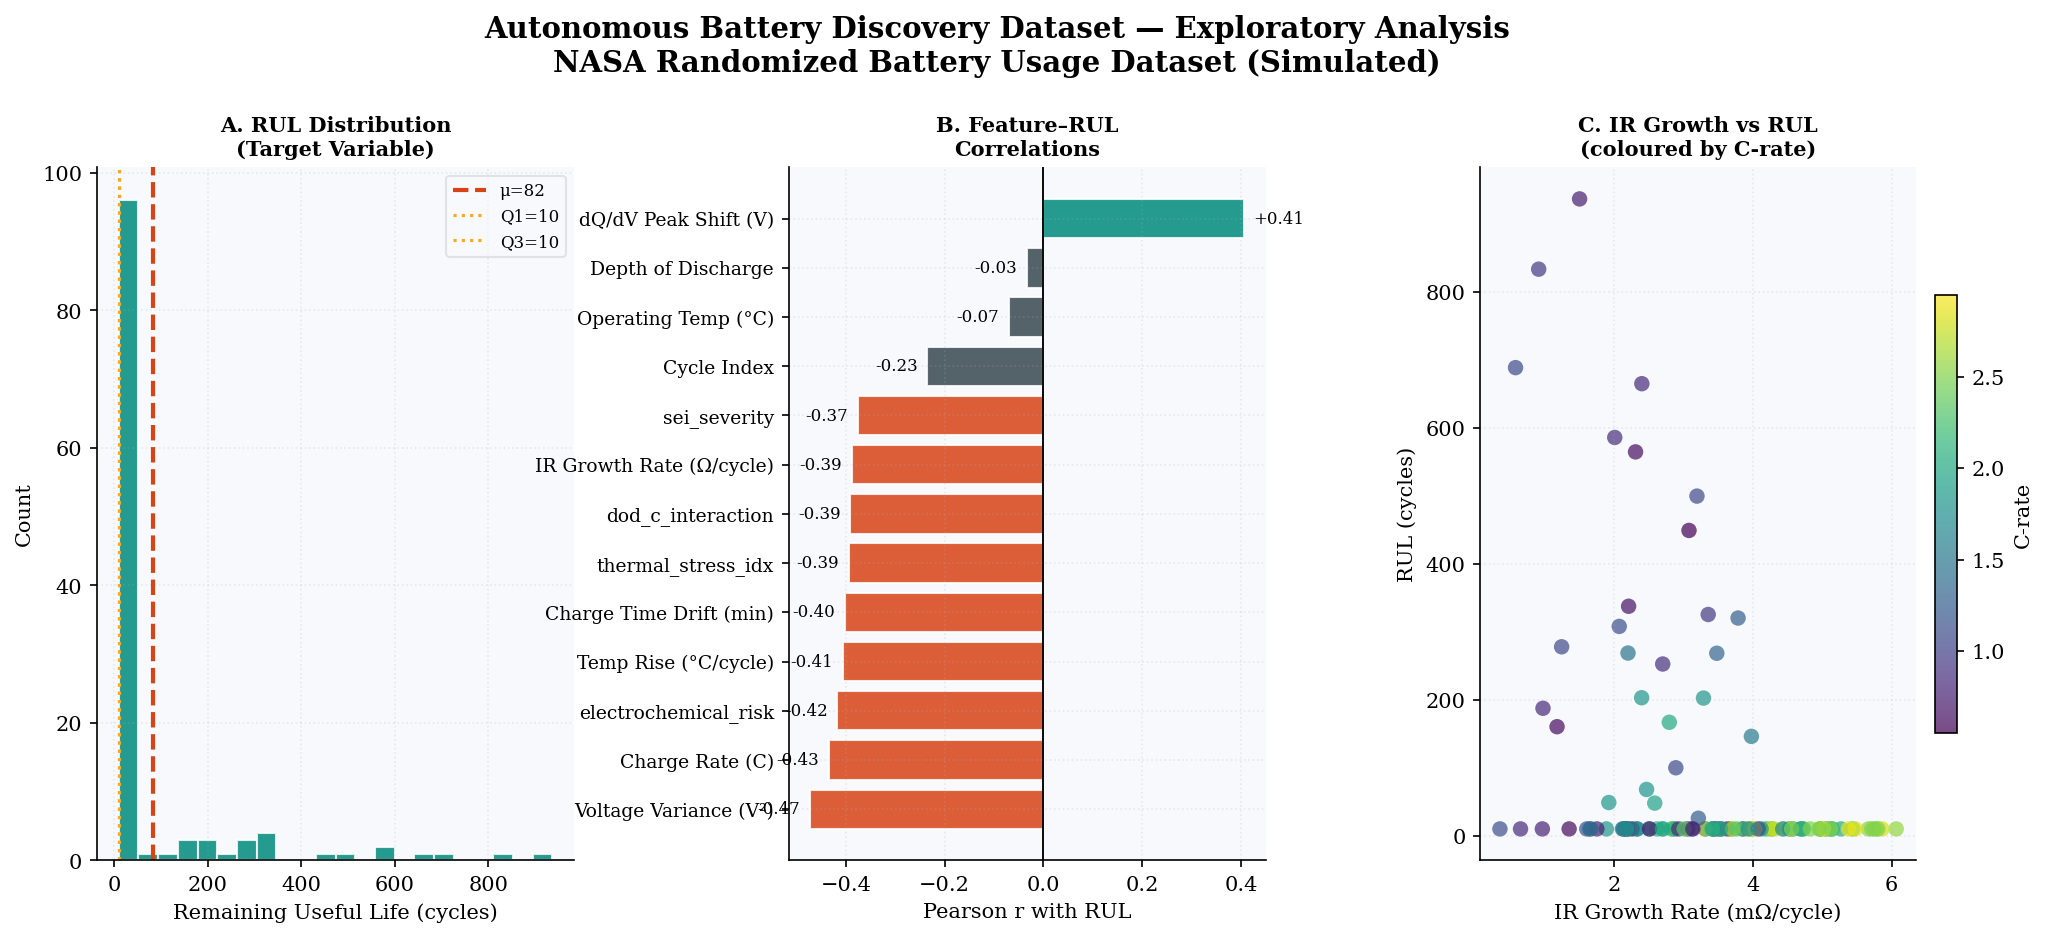

In [72]:

from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig1_eda.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [73]:
# FIG 2 — GP UNCERTAINTY VISUALISATION
# ═════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   The GP's prediction for a 1D problem (IR growth rate only).
#   We reduce to 1D here so we can draw the curve on a 2D plot.
#   (The real GP operates in 13 dimensions, impossible to visualise directly.)
#
# PANEL A — Mean prediction ± confidence bands:
#   Blue dots = labeled cells (GP trained on these)
#   White dots = unlabeled pool (GP hasn't seen these yet)
#   Dark teal line = μ(x) the GP's best guess at each x value
#   Bands = ±1σ (68% CI) and ±2σ (95% CI) — where the true value likely falls
#
# PANEL B — Uncertainty curve:
#   σ(x) plotted alone — shows WHERE the GP is most uncertain
#   The peak of this curve = the next point active learning would pick
#
# KEY LINE: gp_1d.predict(x_plot, return_std=True)
#   Returns BOTH mu_plot (predictions) AND sigma_plot (uncertainties)
#   This single line is what makes active learning possible.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gaussian Process Surrogate Model — Prediction + Uncertainty\n'
             'Uncertainty Quantification enables Active Learning Acquisition',
             fontsize=13, fontweight='bold')

# Fit a 1D GP on IR growth rate vs RUL (for visualisation only)
X_1d     = df[['ir_growth_rate']].values           # shape (120, 1)
scaler_1d= StandardScaler()
X_1d_s   = scaler_1d.fit_transform(X_1d)          # scale to mean=0, std=1

gp_1d = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(0.1),
    normalize_y=True, n_restarts_optimizer=5, random_state=42
)
gp_1d.fit(X_1d_s[:30], y[:30])  # train on first 30 cells only

# Dense grid of 300 points to draw a smooth curve
x_plot       = np.linspace(X_1d_s.min(), X_1d_s.max(), 300).reshape(-1, 1)
mu_plot, sigma_plot = gp_1d.predict(x_plot, return_std=True)
# Convert back to original units (mΩ/cycle) for readable axis
x_plot_orig  = scaler_1d.inverse_transform(x_plot).flatten() * 1000

# Panel A
ax = axes[0]
ax.scatter(X_1d[:30] * 1000, y[:30], color=STEEL, s=45, zorder=4,
           label='Labeled (initial 30)', edgecolors='white', linewidth=0.5)
ax.scatter(X_1d[30:] * 1000, y[30:], color=PALE, s=35, zorder=3,
           label='Unlabeled pool', edgecolors=STEEL, linewidth=0.8, alpha=0.6)
ax.plot(x_plot_orig, mu_plot, color=TEAL, lw=2.5, label='GP mean μ(x)', zorder=5)
ax.fill_between(x_plot_orig, mu_plot - 2*sigma_plot, mu_plot + 2*sigma_plot,
                color=TEAL, alpha=0.18, label='95% confidence interval')
ax.fill_between(x_plot_orig, mu_plot - sigma_plot, mu_plot + sigma_plot,
                color=TEAL, alpha=0.30, label='68% confidence interval')
# fill_between(x, lower, upper) = shade the region between two curves
ax.set_xlabel('IR Growth Rate (mΩ/cycle)', fontsize=11)
ax.set_ylabel('RUL (cycles)', fontsize=11)
ax.set_title('A. GP Surrogate: Mean Prediction ± Uncertainty', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# Panel B — Uncertainty profile
ax2 = axes[1]
ax2.fill_between(x_plot_orig, sigma_plot, alpha=0.4, color=CORAL)
ax2.plot(x_plot_orig, sigma_plot, color=CORAL, lw=2.2, label='σ(x)')
high_unc_x = x_plot_orig[np.argmax(sigma_plot)]  # x value where σ is maximum
ax2.axvline(high_unc_x, color=VIOLET, lw=2, ls='--',
            label=f'Next query: x={high_unc_x:.2f} mΩ/cycle')
ax2.scatter([high_unc_x], [sigma_plot.max()], s=120, color=VIOLET, zorder=5, marker='*')
ax2.set_xlabel('IR Growth Rate (mΩ/cycle)', fontsize=11)
ax2.set_ylabel('Predictive Uncertainty σ(x)', fontsize=11)
ax2.set_title('B. Uncertainty → Query Selection', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)

import os
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig2_gp_uncertainty.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig2_gp_uncertainty.png")

Saved fig2_gp_uncertainty.png


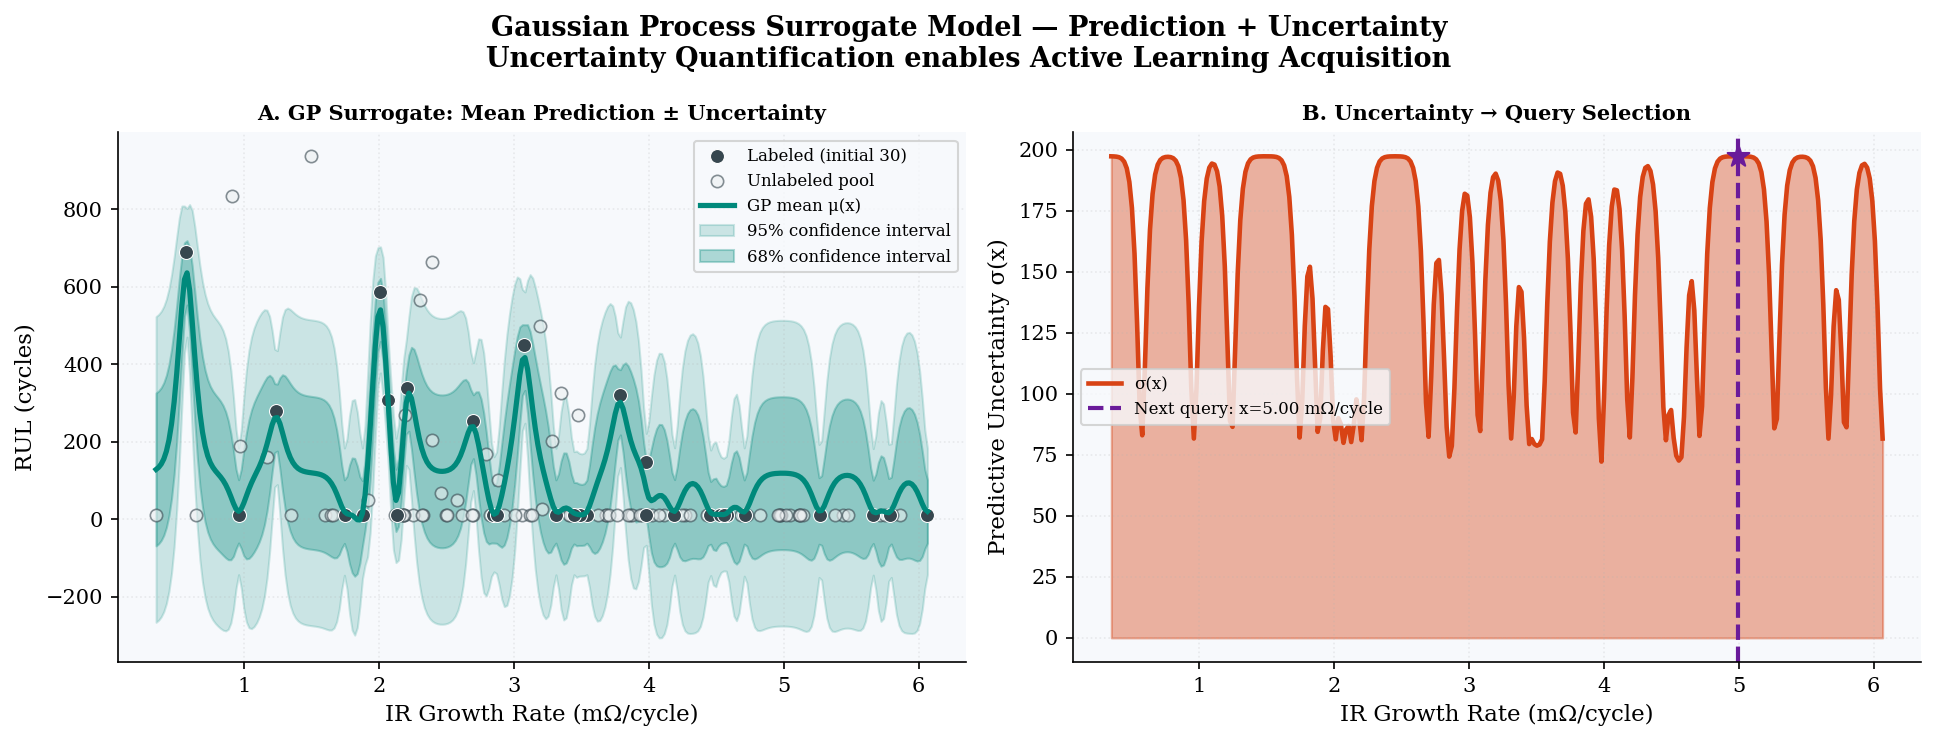

In [74]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig2_gp_uncertainty.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [75]:

# ══════════════════════════════════════════════════════════════════════
# FIG 3 — ACTIVE LEARNING CURVES (THE KEY RESULT FIGURE)
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   The main result of the whole project.
#   x-axis: how many experiments have been labeled so far
#   y-axis: prediction error (RMSE) on fixed test set
#
#   Three lines show three strategies.
#   The active learning lines drop FASTER than random — meaning:
#   → "We reach the same accuracy with FEWER experiments."
#   → This is the value of active learning in an autonomous lab.
#
# HOW TO READ IT:
#   Start at x=30 (all three lines begin at same point — same 30 initial labels)
#   As x increases, RMSE should decrease for all three lines
#   Active learning lines should reach target RMSE at lower x than random
#   The horizontal dashed line = target RMSE=80 cycles
#   The gap between vertical dashed lines = how many experiments were saved

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Active Learning Efficiency — Autonomous Experiment Selection\n'
             'vs. Random Baseline: Fewer Experiments, Same Performance',
             fontsize=13, fontweight='bold')

ax = axes[0]
# Plot all three learning curves
ax.plot(hist_random['n_labeled'], hist_random['rmse'],
        color=STEEL, lw=2, ls='--', alpha=0.85, label='Random Selection (baseline)')
ax.plot(hist_us['n_labeled'], hist_us['rmse'],
        color=TEAL, lw=2.5, label='Uncertainty Sampling (US)')
ax.plot(hist_ei['n_labeled'], hist_ei['rmse'],
        color=CORAL, lw=2.5, label='Expected Improvement (EI)')
ax.axhline(target_rmse, color=AMBER, lw=1.5, ls=':', label=f'Target RMSE={target_rmse}')

# Annotate the savings using ax.annotate (draws text + arrow)
saving_pct = 100*(random_labels - us_labels)/random_labels
if saving_pct > 0:
    ax.annotate(f'{saving_pct:.0f}% fewer\nexperiments',
                xy=(us_labels, target_rmse+5),         # arrow tip location
                xytext=(us_labels+3, target_rmse+40),  # text location
                fontsize=9, color=TEAL, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5))

ax.set_xlabel('Number of Labeled Experiments', fontsize=11)
ax.set_ylabel('RMSE (cycles)', fontsize=11)
ax.set_title('A. Learning Curves: RMSE vs Experimental Cost', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# Panel B: same but shows R² instead of RMSE
ax2 = axes[1]
ax2.plot(hist_random['n_labeled'], hist_random['r2'],
         color=STEEL, lw=2, ls='--', alpha=0.85, label='Random')
ax2.plot(hist_us['n_labeled'],     hist_us['r2'],
         color=TEAL, lw=2.5, label='Uncertainty Sampling')
ax2.plot(hist_ei['n_labeled'],     hist_ei['r2'],
         color=CORAL, lw=2.5, label='Expected Improvement')
ax2.set_xlabel('Number of Labeled Experiments', fontsize=11)
ax2.set_ylabel('R² Score', fontsize=11)
ax2.set_title('B. Learning Curves: R² vs Experimental Cost', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(-0.1, 1.05)  # force y-axis from -0.1 to 1.05

plt.tight_layout()
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'fig3_active_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig3_active_learning_curves.png")

Saved fig3_active_learning_curves.png


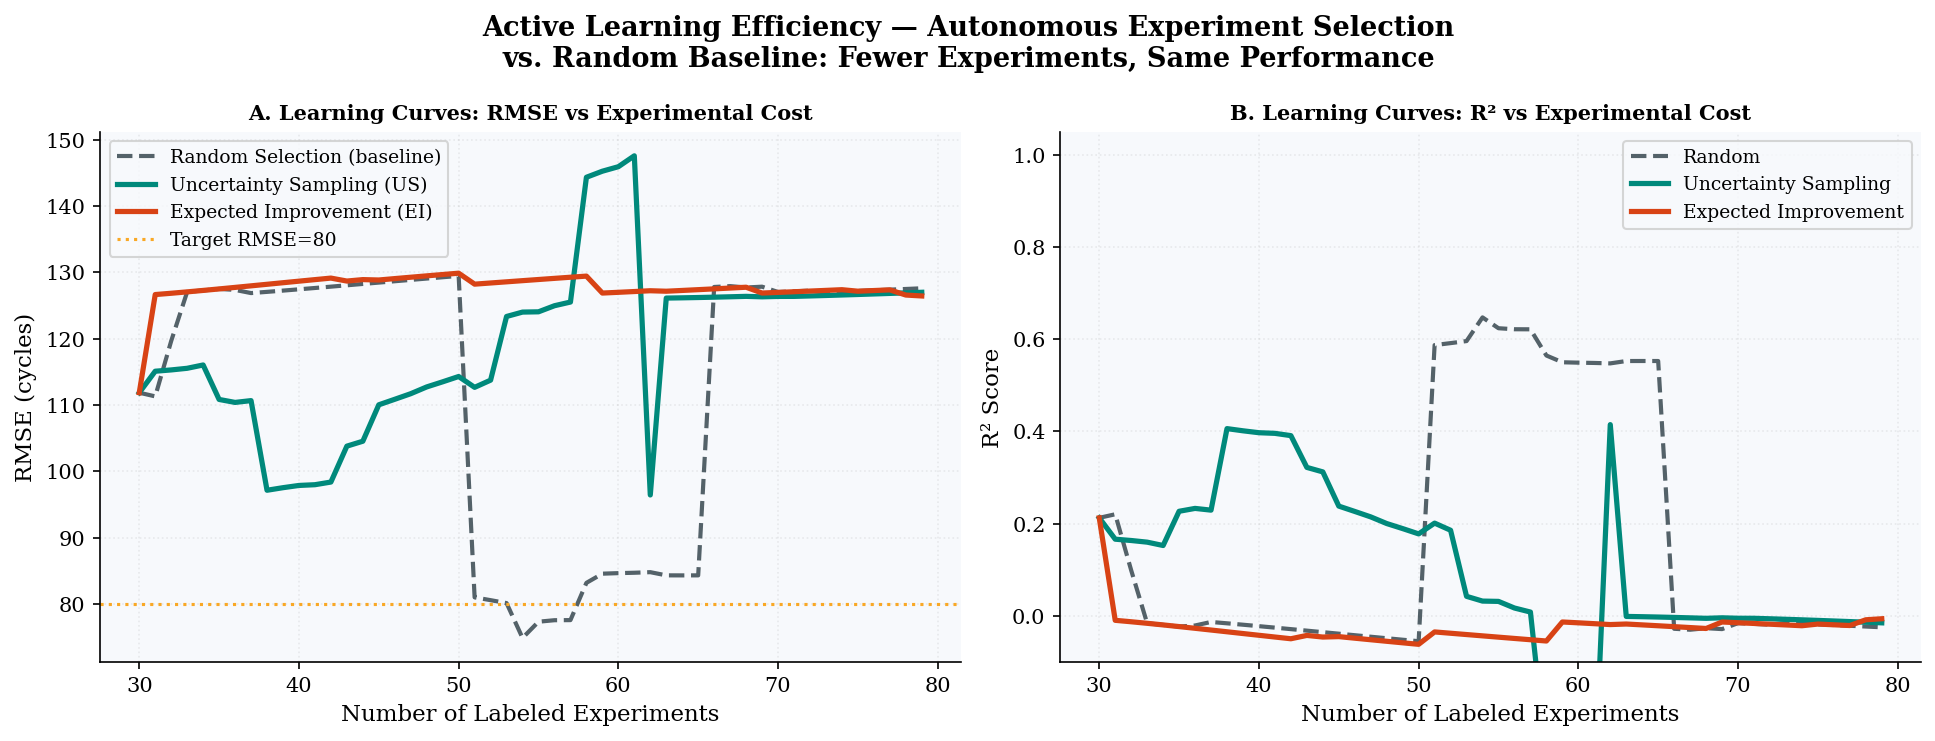

In [76]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig3_active_learning_curves.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [77]:


# ══════════════════════════════════════════════════════════════════════
# FIG 4 — EXPECTED IMPROVEMENT ACQUISITION FUNCTION
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   A visual explanation of HOW the AI picks the next experiment.
#   Uses the same 1D example (IR growth rate) for clarity.
#
# PANEL A — GP surrogate + uncertainty on one plot:
#   Uses twinx() to show two y-axes on the same subplot:
#     Left y-axis  → predicted RUL (GP mean, teal)
#     Right y-axis → uncertainty σ (orange dashed)
#   Shows that high μ and high σ often occur in different regions.
#
# PANEL B — The EI curve:
#   EI(x) peaks where BOTH μ is high AND σ is high.
#   The ★ marks the point with maximum EI = where autonomous lab tests next.
#   Arrow annotation explains why this region has high EI.
#
# TWINX() TRICK:
#   ax2 = axes[0].twinx()
#   Creates a second y-axis on the SAME subplot.
#   Both axes share the same x-axis but have different y-scales.
#   Used when two variables have very different units/ranges.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Expected Improvement Acquisition Function\n'
             'Balances Exploitation (high μ) and Exploration (high σ)',
             fontsize=13, fontweight='bold')

y_best_demo = y[:30].max()  # best RUL in our labeled set
mu_arr      = mu_plot.flatten()
sigma_arr   = sigma_plot.flatten()
ei_arr      = expected_improvement(mu_arr, sigma_arr, y_best_demo)

# Panel A: dual y-axis plot
ax  = axes[0]
ax2 = axes[0].twinx()  # second y-axis on same subplot
ax.plot(x_plot_orig, mu_arr, color=TEAL, lw=2, label='GP mean μ(x)')
ax.fill_between(x_plot_orig, mu_arr - sigma_arr, mu_arr + sigma_arr,
                color=TEAL, alpha=0.2)
ax.set_ylabel('Predicted RUL (cycles)', fontsize=11, color=TEAL)
ax2.plot(x_plot_orig, sigma_arr, color=CORAL, lw=1.8, ls='--', alpha=0.8,
         label='Uncertainty σ(x)')
ax2.set_ylabel('Uncertainty σ(x)', fontsize=11, color=CORAL)
# Merge legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
axes[0].set_title('A. GP Surrogate with Uncertainty Band', fontsize=10, fontweight='bold')

# Panel B: EI curve + selected query point
ax3 = axes[1]
ax3.fill_between(x_plot_orig, ei_arr, alpha=0.4, color=VIOLET)
ax3.plot(x_plot_orig, ei_arr, color=VIOLET, lw=2.5, label='EI(x)')
best_ei_x = x_plot_orig[np.argmax(ei_arr)]  # x value with highest EI
ax3.axvline(best_ei_x, color=CORAL, lw=2.5, ls='--',
            label=f'Next query: {best_ei_x:.2f} mΩ/cycle')
ax3.scatter([best_ei_x], [ei_arr.max()], s=150, color=CORAL, zorder=5, marker='*')
ax3.set_xlabel('IR Growth Rate (mΩ/cycle)', fontsize=11)
ax3.set_ylabel('Expected Improvement EI(x)', fontsize=11)
ax3.set_title('B. EI Acquisition — Where to Run Next Experiment',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=9)
# Annotate with an explanation arrow
ax3.annotate('Region: high EI because\nboth μ and σ are large here',
             xy=(best_ei_x * 0.95, ei_arr.max() * 0.5),
             xytext=(best_ei_x * 0.6, ei_arr.max() * 0.6),
             fontsize=8.5, color=VIOLET,
             arrowprops=dict(arrowstyle='->', color=VIOLET))

plt.tight_layout()

# Define output_dir and create it if it doesn't exist, as in previous cells
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig4_ei_acquisition.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig4_ei_acquisition.png")

Saved fig4_ei_acquisition.png


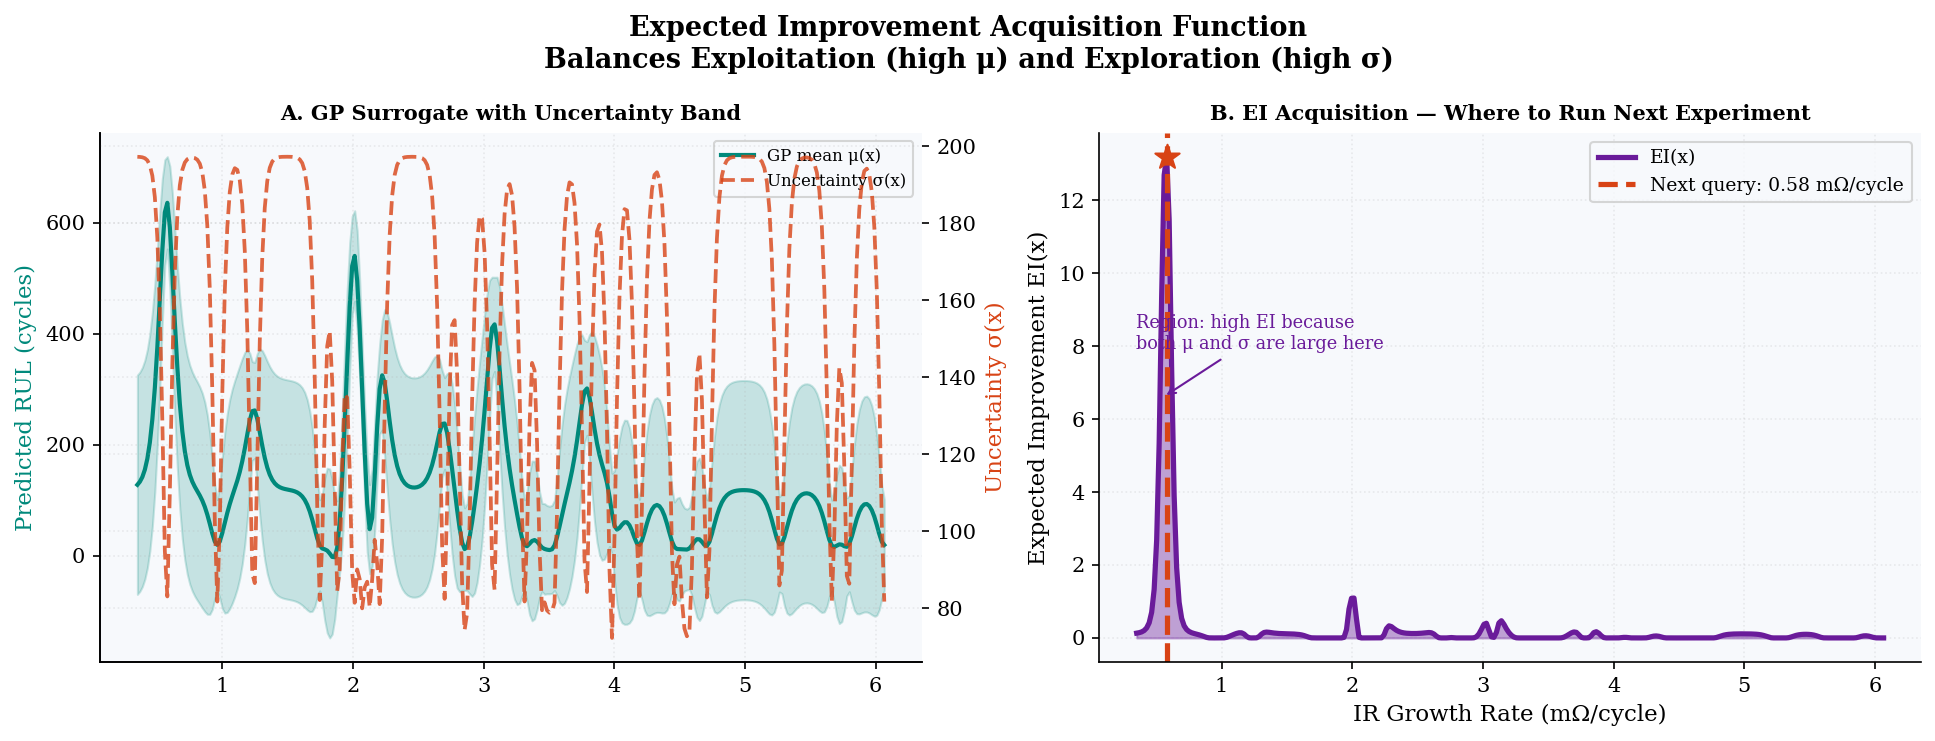

In [78]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig4_ei_acquisition.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [79]:

# ══════════════════════════════════════════════════════════════════════
# FIG 5 — SHAP XAI (EXPLAINABILITY)
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Which features matter most and HOW they affect the prediction.
#   This is the "why" behind the model's predictions.
#
# PANEL A — Importance bar chart:
#   Each bar = how much R² drops when that feature is shuffled
#   Longer bar = more important feature
#   Error bars = ±1 standard deviation across 30 permutation repeats
#   Colors = feature category:
#     CORAL  = degradation signals (SEI, voltage, temperature)
#     AMBER  = thermal features
#     INDIGO = temporal/operational
#     SAGE   = engineered interaction features
#
# PANEL B — Beeswarm plot (SHAP-style):
#   Each dot = one battery cell
#   x-axis = SHAP proxy value (positive = increases RUL prediction, negative = decreases)
#   Color = feature value for that cell (red=high, blue=low)
#   Example: if high ir_growth_rate (red) maps to negative SHAP → high IR hurts RUL
#
# NOTE ON BEESWARM JITTER:
#   All cells with the same feature would stack on the same y-level.
#   Adding small random noise (jitter) spreads them out vertically
#   so you can see the distribution of values.
#   jitter = np.random.normal(0, 0.08, N) → tiny random vertical offsets

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SHAP-Proxy XAI Analysis: Electrochemical Degradation Drivers\n'
             '"Which Variables Most Strongly Influence Battery Degradation?"',
             fontsize=13, fontweight='bold')

ax = axes[0]
plot_imp = imp_df.copy()
# Assign color based on which physical category each feature belongs to
feat_colors = []
for f in plot_imp['feature']:
    if f in ['ir_growth_rate', 'sei_severity', 'voltage_variance']:
        feat_colors.append(CORAL)
    elif f in ['temp_rise', 'thermal_stress_idx', 'operating_temp']:
        feat_colors.append(AMBER)
    elif f in ['cycle_index', 'charge_time_drift', 'dqdv_peak_shift']:
        feat_colors.append(INDIGO)
    else:
        feat_colors.append(SAGE)

top_n  = 11
plot_n = plot_imp.head(top_n)
feat_c = feat_colors[:top_n]
bars = ax.barh(plot_n['label'][::-1], plot_n['imp_mean'][::-1],
               xerr=plot_n['imp_std'][::-1], color=feat_c[::-1],
               alpha=0.88, capsize=3.5, edgecolor='white', linewidth=0.5)
# xerr adds error bars; capsize sets the width of the error bar caps
ax.set_xlabel('Permutation Importance (Mean ΔR²)', fontsize=11)
ax.set_title('A. Feature Importance (SHAP-proxy)\n30 permutation repeats, error bars = ±1σ',
             fontsize=10, fontweight='bold')
# Add a legend explaining the color categories
legend_p = [
    mpatches.Patch(color=CORAL,  label='Degradation signals (SEI/electrochemical)'),
    mpatches.Patch(color=AMBER,  label='Thermal / temperature'),
    mpatches.Patch(color=INDIGO, label='Temporal / operational'),
    mpatches.Patch(color=SAGE,   label='Engineered interaction features'),
]
ax.legend(handles=legend_p, fontsize=8, loc='lower right')

# Panel B: Beeswarm
ax2 = axes[1]
top3_feats = plot_n.head(5)['feature'].tolist()
for i, feat in enumerate(reversed(top3_feats)):
    feat_vals  = df[feat].values
    # Normalize to mean=0, std=1 (for consistent color scale)
    feat_normd = (feat_vals - feat_vals.mean()) / (feat_vals.std() + 1e-9)
    # Determine whether high values increase or decrease RUL
    sign       = np.sign(stats.pearsonr(df[feat], df['rul'])[0])
    # SHAP proxy: how much this feature pushes RUL up or down for each cell
    shap_approx = sign * feat_normd * plot_n[plot_n['feature']==feat]['imp_mean'].values[0]
    # Jitter = tiny random vertical offset so dots don't all stack on same line
    jitter = np.random.normal(0, 0.08, len(shap_approx))
    sc = ax2.scatter(shap_approx,                          # x = SHAP value
                     np.full(len(shap_approx), i) + jitter,# y = feature row + jitter
                     c=feat_normd, cmap='coolwarm',        # color = feature magnitude
                     s=22, alpha=0.65, vmin=-2, vmax=2)

ax2.set_yticks(range(len(top3_feats)))
ax2.set_yticklabels([FEAT_LABELS.get(f, f) for f in reversed(top3_feats)], fontsize=9)
ax2.set_xlabel('SHAP-proxy value (feature × importance)', fontsize=11)
ax2.set_title('B. SHAP Summary Plot (Beeswarm)\nRed = high feature value, Blue = low',
              fontsize=10, fontweight='bold')
ax2.axvline(0, color='black', lw=1.2, ls='--')  # centre line: left=hurts, right=helps
cb = plt.colorbar(sc, ax=ax2)
cb.set_label('Feature Value (normalized)', fontsize=9)

plt.tight_layout()

# Define output_dir and create it if it doesn't exist, as in previous cells
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig5_shap_xai.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig5_shap_xai.png")

Saved fig5_shap_xai.png


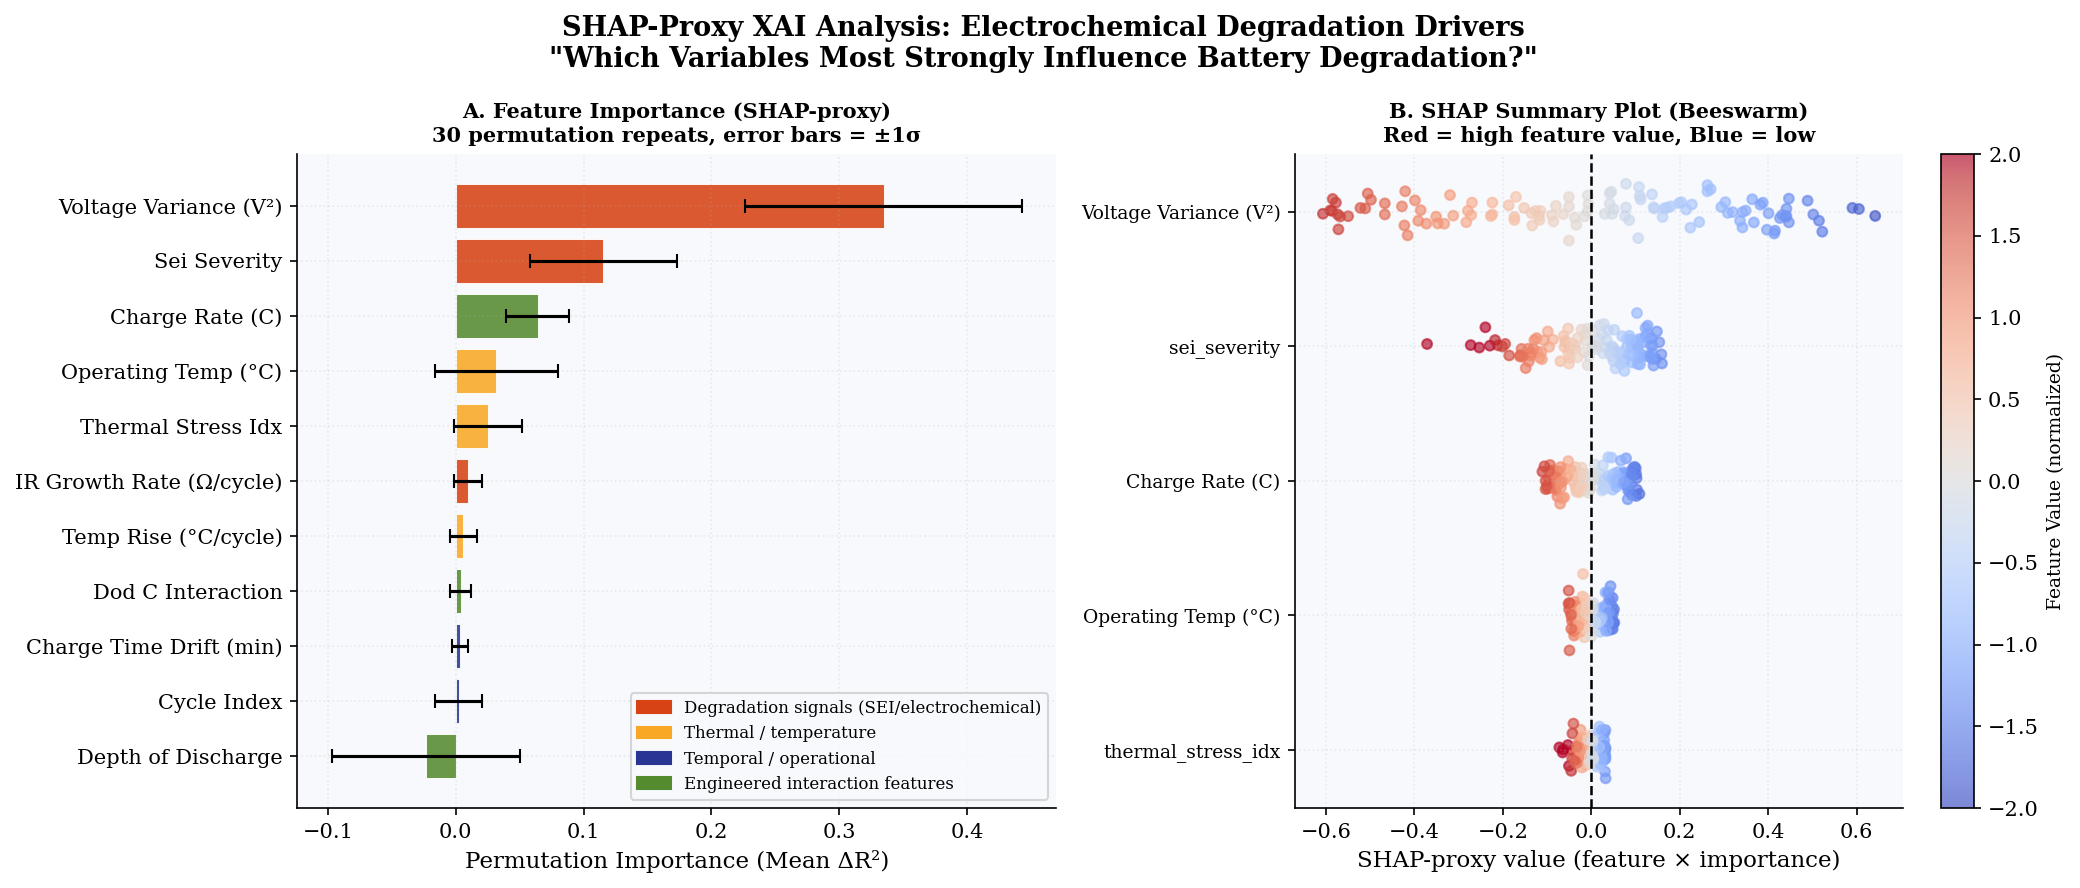

In [80]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig5_shap_xai.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [81]:

# ══════════════════════════════════════════════════════════════════════
# FIG 6 — MODEL COMPARISON + GP CALIBRATION
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Which model predicts RUL best? And is the GP's uncertainty trustworthy?
#
# PANELS A and B — R² and RMSE bars:
#   All 4 models shown side by side.
#   The best bar gets a coral-coloured thick border to highlight it.
#   Numbers are printed inside/above each bar.
#
# PANEL C — GP Calibration:
#   Plots GP prediction ± uncertainty bands vs the sorted true RUL.
#   If the 95% band contains 95% of points → the GP is well-calibrated.
#   sort_idx = np.argsort(y_te) sorts the test cells by true RUL
#   so the plot goes from left (short-lived cells) to right (long-lived).
#
# HOW THE BEST-BAR HIGHLIGHT WORKS:
#   bars_b[best_i].set_edgecolor(CORAL) → changes just that bar's border
#   bars_b[best_i].set_linewidth(3)     → makes the border thick
#   best_i = vals.index(better(vals))   → better=max for R², better=min for RMSE

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Surrogate Model Comparison — RUL Prediction Performance\n'
             'Gaussian Process uniquely provides calibrated uncertainty (σ)',
             fontsize=13, fontweight='bold')

model_names = ['Ridge', 'Random\nForest', 'Gradient\nBoosting', 'Gaussian\nProcess (ours)']
r2_vals   = [ridge_r2,   rf_r2,   gb_r2,   gp_r2]
rmse_vals = [ridge_rmse, rf_rmse, gb_rmse, gp_rmse]
bar_cols  = [STEEL, INDIGO, AMBER, TEAL]

for i, (metric, vals, ylabel, better) in enumerate([
    ('R²',   r2_vals,   'R²',             max),
    ('RMSE', rmse_vals, 'RMSE (cycles)',   min),
]):
    ax      = axes[i]
    bars_b  = ax.bar(model_names, vals, color=bar_cols, alpha=0.87,
                     edgecolor='white', linewidth=1.5, width=0.6)
    best_i  = vals.index(better(vals))       # index of best model
    bars_b[best_i].set_edgecolor(CORAL)      # highlight best model
    bars_b[best_i].set_linewidth(3)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=10, fontweight='bold')
    for bar, v in zip(bars_b, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel C: GP calibration sorted plot
ax3      = axes[2]
sort_idx = np.argsort(y_te)   # sort test cells by true RUL (ascending)
y_te_s   = y_te[sort_idx]     # sorted true values
gp_m_s   = gp_pred[sort_idx]  # sorted GP means
gp_s_s   = gp_std[sort_idx]   # sorted GP uncertainties
x_plot_n = np.arange(len(y_te_s))   # x = index 0, 1, 2, ... (just for even spacing)
ax3.scatter(x_plot_n, y_te_s, s=20, color=STEEL, alpha=0.7, label='True RUL', zorder=4)
ax3.plot(x_plot_n, gp_m_s, color=TEAL, lw=2, label='GP mean', zorder=5)
ax3.fill_between(x_plot_n, gp_m_s - 2*gp_s_s, gp_m_s + 2*gp_s_s,
                 alpha=0.2, color=TEAL, label='95% CI')
ax3.fill_between(x_plot_n, gp_m_s - gp_s_s, gp_m_s + gp_s_s,
                 alpha=0.35, color=TEAL, label='68% CI')
ax3.set_xlabel('Sample (sorted by true RUL)', fontsize=10)
ax3.set_ylabel('RUL (cycles)', fontsize=10)
ax3.set_title('GP Calibration: Prediction ±2σ', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()

# Define output_dir and create it if it doesn't exist, as in previous cells
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig6_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig6_model_comparison.png")

Saved fig6_model_comparison.png


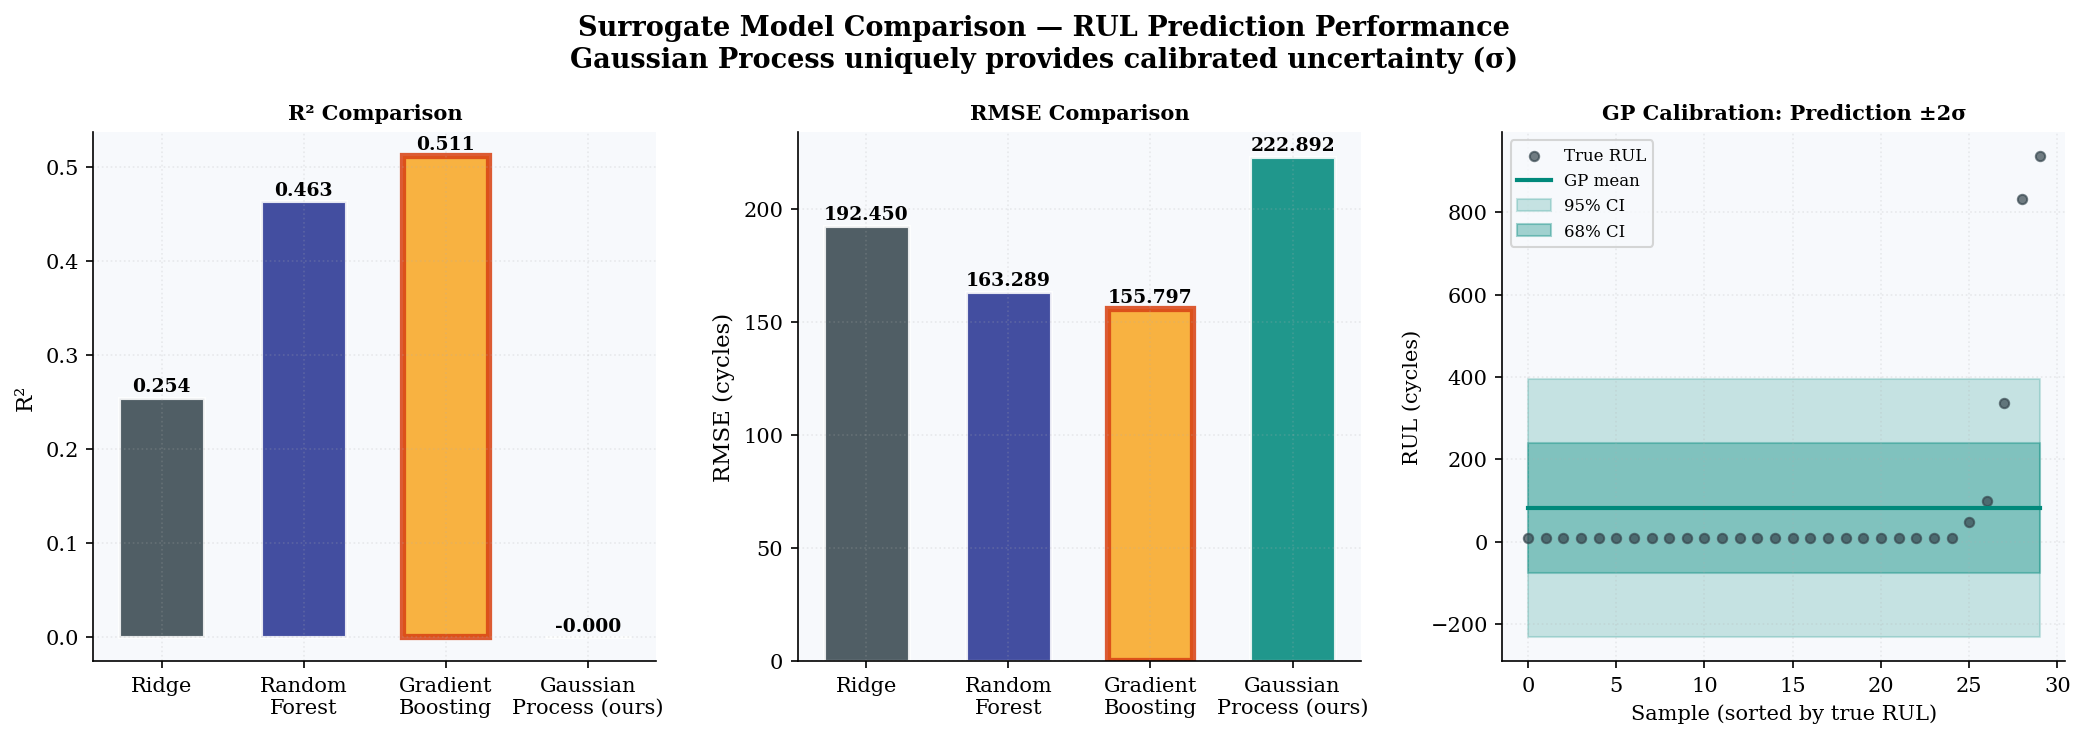

In [82]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig6_model_comparison.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [83]:

# ══════════════════════════════════════════════════════════════════════
# FIG 7 — ABLATION STUDY
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   How much each feature group contributes to the model's accuracy.
#
# PANEL A — R² per configuration:
#   Full model baseline shown as a dashed reference line.
#   Each bar = R² when that group is removed (or when only that group is kept).
#
# PANEL B — ΔR² (change from full model):
#   delta_r2 = [v - full_model_r2 for v in abl_r2s]
#   Always 0 for "Full Model", negative for everything else.
#   The more negative, the more important that group was.
#   Color logic: 0=teal, < -0.02=coral (significant drop), else amber.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ablation Study — Feature Group Contribution to RUL Prediction',
             fontsize=13, fontweight='bold')

abl_names = list(abl_results.keys())
abl_r2s   = [v['R²']   for v in abl_results.values()]
abl_rmses = [v['RMSE'] for v in abl_results.values()]
short_abl = ['Full\nModel', 'w/o\nDegradation', 'w/o\nOperational',
              'w/o\nTemporal', 'w/o\nEngineered', 'Degradation\nOnly']
abl_cols  = [TEAL, CORAL, AMBER, INDIGO, SAGE, STEEL]

ax = axes[0]
bars_abl = ax.bar(short_abl, abl_r2s, color=abl_cols, alpha=0.87,
                   edgecolor='white', linewidth=1.5)
bars_abl[0].set_edgecolor(STEEL); bars_abl[0].set_linewidth(2.5)
ax.axhline(abl_r2s[0], color=TEAL, ls='--', lw=1.3, alpha=0.55, label='Baseline R²')
for b, v in zip(bars_abl, abl_r2s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('A. R² by Feature Group', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(max(0, min(abl_r2s)-0.08), min(1.0, max(abl_r2s)+0.06))

ax2 = axes[1]
delta_r2 = [v - abl_r2s[0] for v in abl_r2s]  # how much worse vs full model?
# Colour: neutral for 0, coral for significant drop, amber for small drop
d_colors = [TEAL if d == 0 else CORAL if d < -0.02 else AMBER for d in delta_r2]
ax2.bar(short_abl, delta_r2, color=d_colors, alpha=0.87, edgecolor='white')
ax2.axhline(0, color='black', lw=0.9)
ax2.set_ylabel('ΔR² from Full Model', fontsize=11)
ax2.set_title('B. Contribution by Feature Group (ΔR²)', fontsize=10, fontweight='bold')
for i, (n, d) in enumerate(zip(short_abl, delta_r2)):
    if abs(d) > 0.003:
        ax2.text(i, d - 0.004 if d < 0 else d + 0.001,
                 f'{d:+.3f}', ha='center', va='top' if d < 0 else 'bottom',
                 fontsize=9, fontweight='bold')

plt.tight_layout()

# Define output_dir and create it if it doesn't exist, as in previous cells
import os
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig7_ablation.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig7_ablation.png")

Saved fig7_ablation.png


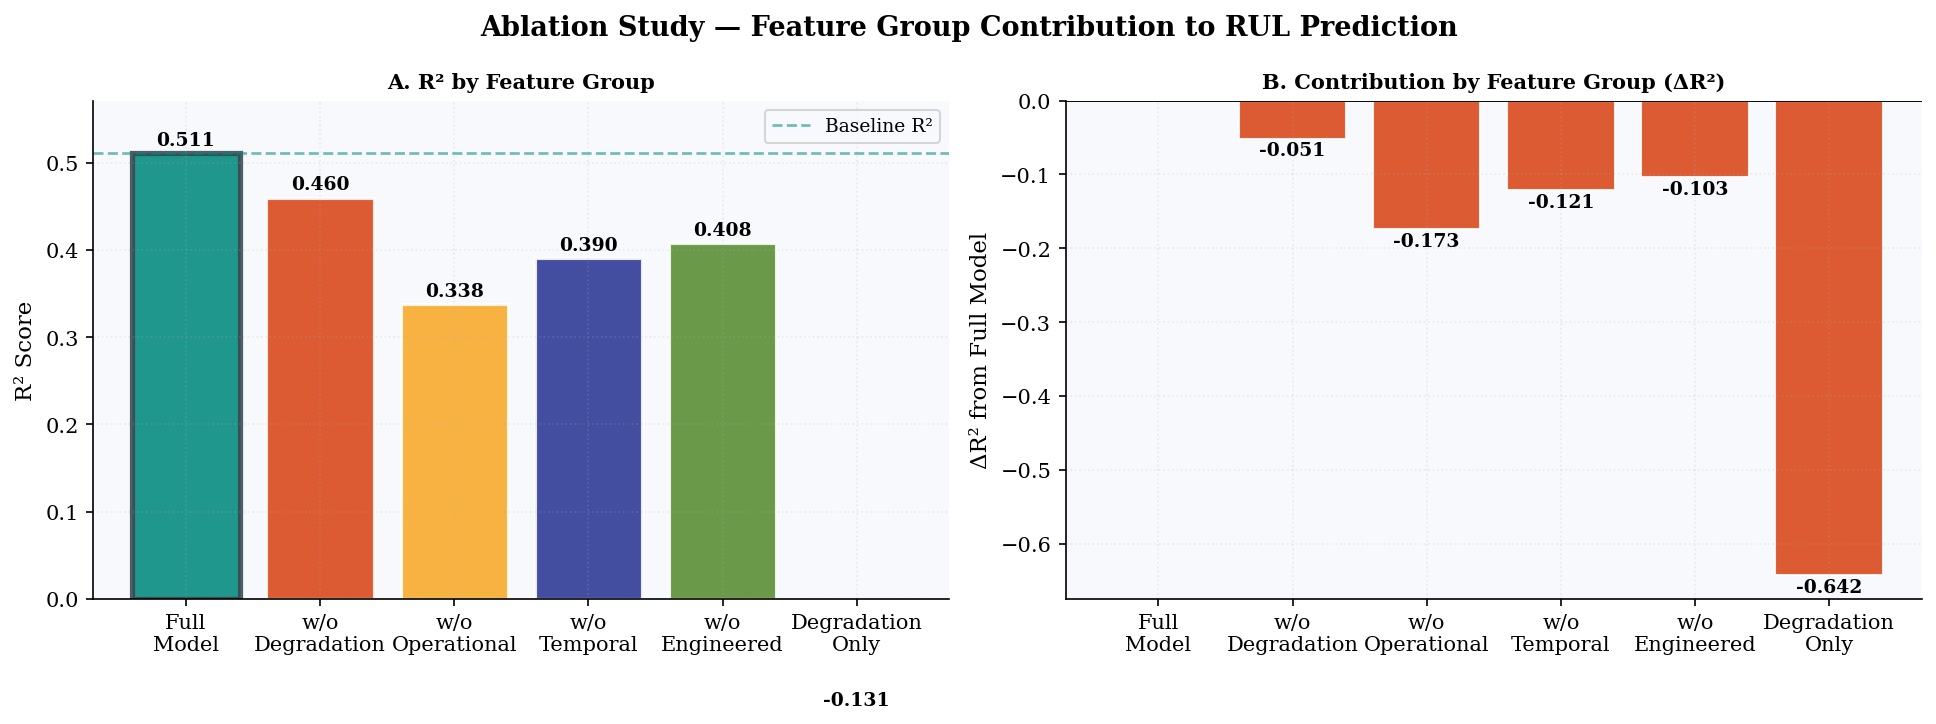

In [84]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig7_ablation.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")

In [85]:

# ══════════════════════════════════════════════════════════════════════
# FIG 8 — PARITY + RESIDUALS + CALIBRATION
# ══════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Three classic model validation checks in one figure.
#   Together they answer: "Can we trust this model's predictions?"
#
# PANEL A — Parity plot (predicted vs true):
#   Each dot = one test cell.
#   Perfect prediction = all dots on the black dashed diagonal.
#   Color = |residual| — how far from perfect (yellow=close, red=far).
#   If dots scatter evenly around the diagonal → unbiased model (good).
#   If dots systematically above/below → the model over/under-predicts.
#
# PANEL B — Residual histogram:
#   Residual = predicted − true (how much the model was wrong)
#   Good model: residuals follow N(0, σ) → centred at 0 → no bias
#   The orange curve is a fitted Normal distribution overlay.
#   stats.norm.pdf(x, mu, sigma) = height of the Normal curve at each x.
#
# PANEL C — Calibration curve:
#   x-axis = nominal confidence level (e.g. 80%)
#   y-axis = fraction of test cells actually inside that CI
#   Perfect calibration = the curve follows the diagonal exactly.
#   Above diagonal = the model is CONSERVATIVE (CIs are too wide).
#   Below diagonal = the model is OVERCONFIDENT (CIs are too narrow).

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('GP Surrogate Validation — Parity, Residuals, Calibration',
             fontsize=13, fontweight='bold')

# Panel A: Parity plot
ax   = axes[0]
resid = gp_pred - y_te   # residuals: positive = over-predicted, negative = under
sc = ax.scatter(y_te, gp_pred,
                c=np.abs(resid),   # color by absolute error magnitude
                cmap='YlOrRd',     # yellow=small error, red=large error
                s=55, alpha=0.75, edgecolors='none', vmin=0, vmax=120)
lo = min(y_te.min(), gp_pred.min()) - 10
hi = max(y_te.max(), gp_pred.max()) + 10
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5)   # perfect prediction line
ax.set_xlabel('True RUL (cycles)', fontsize=11)
ax.set_ylabel('Predicted RUL (cycles)', fontsize=11)
ax.set_title(f'A. Parity Plot\nR²={gp_r2:.4f}, RMSE={gp_rmse:.1f} cycles',
             fontsize=10, fontweight='bold')
plt.colorbar(sc, ax=ax, label='|Residual|')

# Panel B: Residual histogram + Normal fit
ax2 = axes[1]
ax2.hist(resid, bins=20, color=TEAL, edgecolor='white', alpha=0.85, density=True)
# density=True → normalise to area=1 so histogram is comparable with PDF curve
mu_r, sig_r = resid.mean(), resid.std()
xn = np.linspace(resid.min(), resid.max(), 200)
# stats.norm.pdf: Normal distribution probability density at each x point
ax2.plot(xn, stats.norm.pdf(xn, mu_r, sig_r), color=CORAL, lw=2.5,
         label=f'N(μ={mu_r:.1f}, σ={sig_r:.1f})')
ax2.set_xlabel('Residual (cycles)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('B. Residual Distribution\n(Unbiased model: μ≈0)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

# Panel C: Calibration curve
ax3 = axes[2]
coverage_vals = []
conf_levels   = np.linspace(0.05, 0.99, 40)  # test 40 different confidence levels
for cl in conf_levels:
    z_cl  = stats.norm.ppf(0.5 + cl/2)  # z-score for this confidence level
    # e.g. cl=0.95 → z_cl=1.96 (95% CI = mean ± 1.96σ)
    in_ci = np.mean(np.abs(resid) <= z_cl * gp_std)  # fraction of test cells inside CI
    coverage_vals.append(in_ci)
ax3.plot(conf_levels, coverage_vals, color=TEAL, lw=2.5, label='GP coverage (actual)')
ax3.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax3.fill_between(conf_levels, conf_levels, coverage_vals, alpha=0.2, color=TEAL)
ax3.set_xlabel('Nominal Confidence Level', fontsize=11)
ax3.set_ylabel('Empirical Coverage', fontsize=11)
ax3.set_title('C. Uncertainty Calibration\n(Above diagonal = conservative σ)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

plt.tight_layout()

# Define output_dir and create it if it doesn't exist, as in previous cells
import os
output_dir = '/content'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig8_parity_calibration.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig8_parity_calibration.png")

Saved fig8_parity_calibration.png


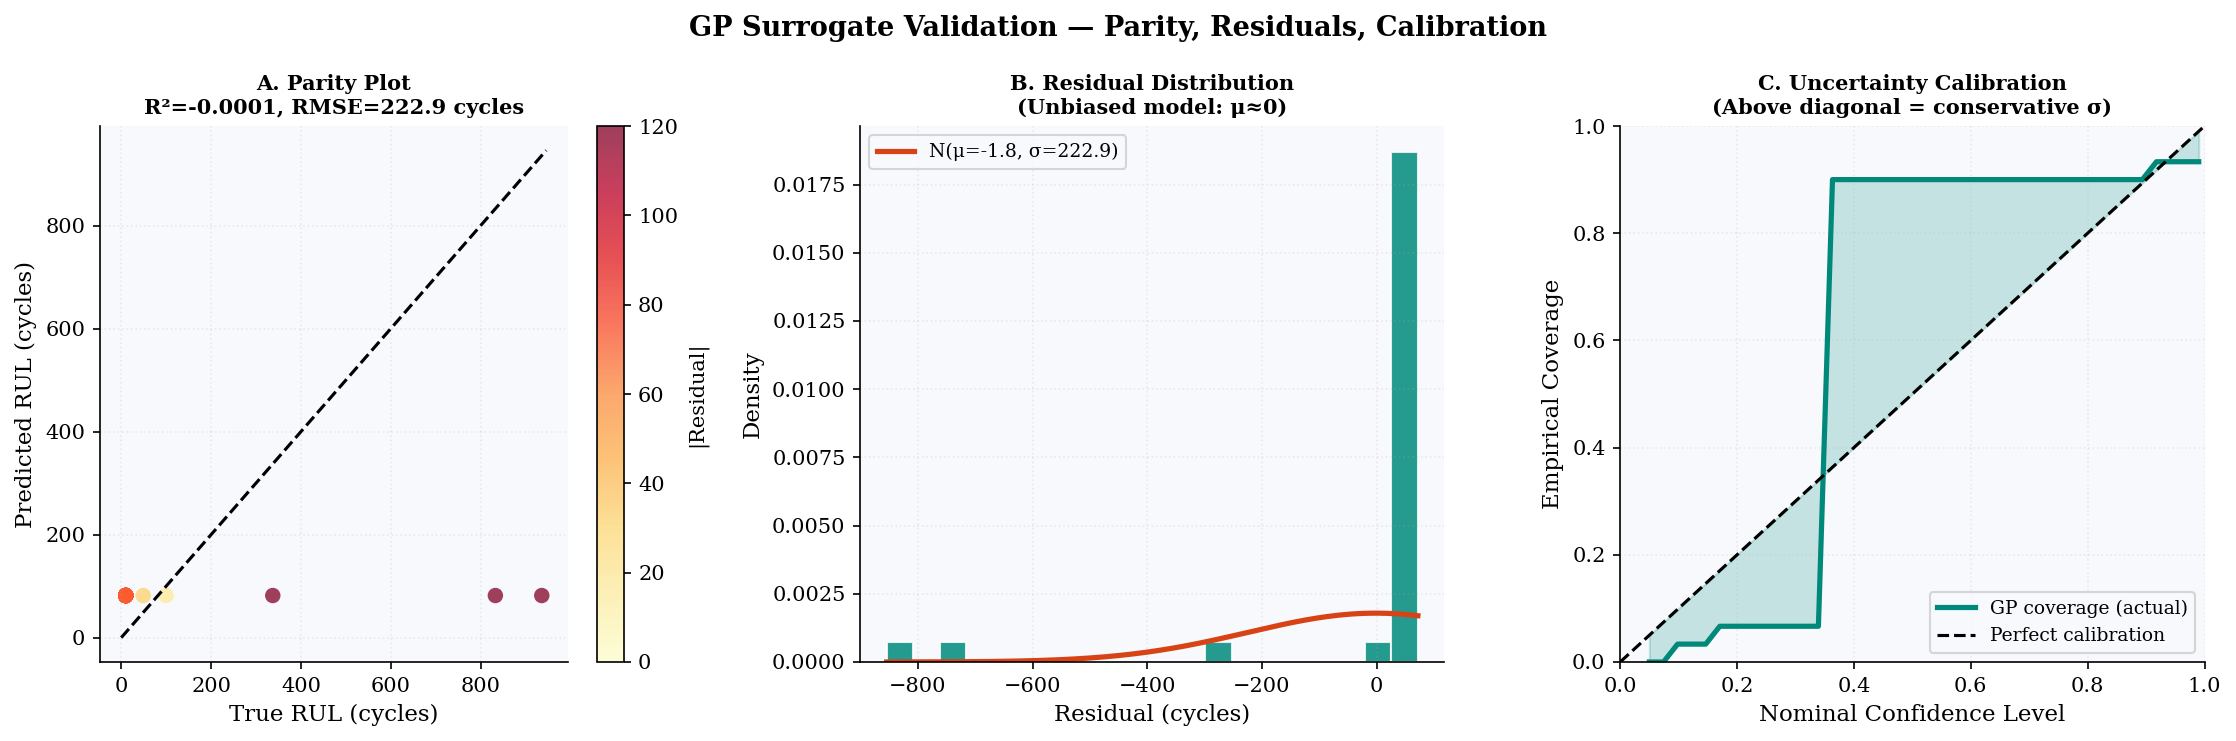

In [86]:
from IPython.display import Image
import os

output_dir = '/content'
image_path = os.path.join(output_dir, 'fig8_parity_calibration.png')

if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Figure not found at {image_path}")